# 01 — Gene expression (SSA/Gillespie)

This notebook demonstrates the full tibs stack:
- Instantiate a toy gene-expression model
- Run a stochastic simulation (SSA/Gillespie)
- Compute simple time-series features (AUC, peak, time-to-halfmax)
- Plot the trajectory


In [9]:
import matplotlib.pyplot as plt
import numpy as np

from tibs.features.timeseries import auc, peak, time_to_halfmax
from tibs.models.gene_expression import GeneExpression
from tibs.simulators.ssa import gillespie

print("Imports OK")

Imports OK


## 1) Instantiate the model

We assume the model exposes:
- `initial_state()`
- `parameters()`
- `stoichiometry()`
- `propensities(x, t, p)`


In [10]:
model = GeneExpression()
x0 = model.initial_state()
p = model.parameters()

print("initial_state:", x0)
print("parameters:", p)
print("stoichiometry shape:", np.asarray(model.stoichiometry()).shape)

initial_state: [0. 0.]
parameters: {'k_tx': 1.0, 'k_tl': 5.0, 'gamma_m': 0.2, 'gamma_p': 0.05}
stoichiometry shape: (2, 4)


## 2) Run SSA / Gillespie

The simulator returns `(times, states)`.


In [11]:
t, X = gillespie(model, t_max=100.0, seed=0)

print("t shape:", t.shape)
print("X shape:", X.shape)
print("final time:", t[-1])
print("final state:", X[-1])

t shape: (4130,)
X shape: (4130, 2)
final time: 99.97343597759463
final state: [  3. 324.]


## 3) Compute simple features

We’ll compute features on the second species (index 1), which is commonly protein.
If your model defines species differently, change `species_idx`.


In [12]:
species_idx = 1
y = X[:, species_idx]

print("AUC:", auc(t, y))
print("Peak:", peak(y))
print("Time to half-max:", time_to_halfmax(t, y))

AUC: 35176.87105228279
Peak: 527.0
Time to half-max: 16.27454052943887


## 4) Plot one trajectory


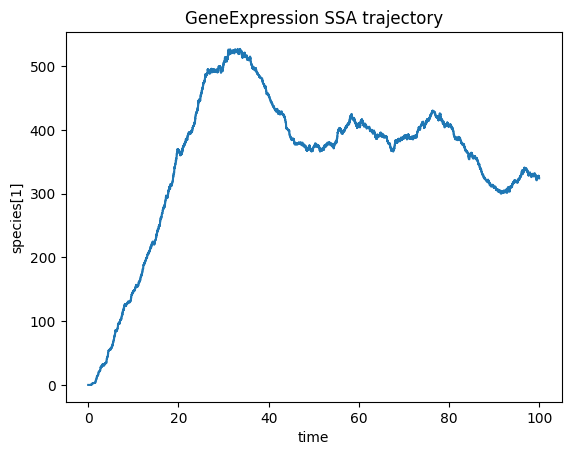

In [13]:
plt.figure()
plt.step(t, y, where="post")
plt.xlabel("time")
plt.ylabel(f"species[{species_idx}]")
plt.title("GeneExpression SSA trajectory")
plt.show()

## 5) (Optional) Run a small ensemble

This gives a feel for stochastic variability.


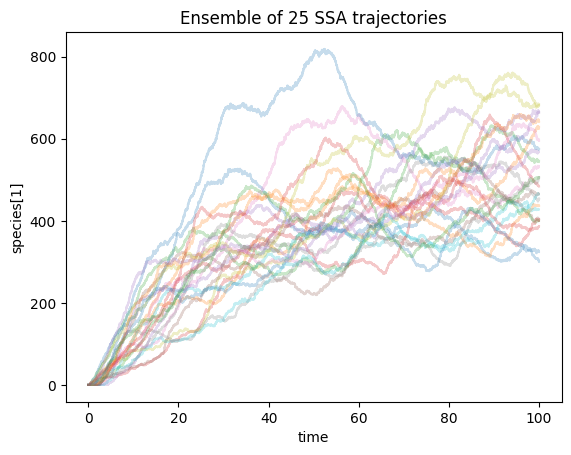

In [14]:
n = 25
ys = []

for s in range(n):
    t_s, X_s = gillespie(model, t_max=100.0, seed=s)
    ys.append((t_s, X_s[:, species_idx]))

plt.figure()
for t_s, y_s in ys:
    plt.step(t_s, y_s, where="post", alpha=0.25)
plt.xlabel("time")
plt.ylabel(f"species[{species_idx}]")
plt.title(f"Ensemble of {n} SSA trajectories")
plt.show()